<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">
    
## Why an RNN?

Recurrent Neural Networks (RNNs, e.g. LSTMs, GRUs) were among the *first deep learning models* applied to molecular generation via SMILES.  
They demonstrated that molecules could be treated like sequences and generated character by character, much like natural language.

**Industry note:**  
Today, RNNs are largely replaced by **transformer-based models** (e.g. ChemBERTa, MolBERT, MegaMolBART) for SMILES, and by **graph transformers** or **diffusion models** for structure-aware generation.  

In this notebook, the RNN serves as a **didactic baseline**:
- It shows the *foundations* of molecular language modeling.  
- It provides an interpretable starting point before moving to more advanced models (transformers, diffusion).  
- It illustrates key evaluation metrics (validity, novelty, uniqueness, QED/logP distributions) that remain standard across modern generative approaches.

</div>

<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">

The goal is to set up a **RNN** that can generate new SMILES strings. The network is trained on a set of canonized SMILES strings, and is used as a generator.
We need to code the part where we sample from the trained token distributions (autoregressive generator): one token after the other
We test test some of those structures in terms of properties

Need to add a description of the working idea behind the RNN...it might take a while

</div>

In [1]:
import numpy as np, pandas as pd, os, math, random
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors


import matplotlib
%matplotlib inline

import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


We train on the ZINC250k dataset (a curated drug-like subset of ZINC15, widely used in ML generative chemistry). This provides a diverse set of ~250k drug-like molecules for training a SMILES RNN

In [2]:
input_data = os.path.join('data', '250k_rndm_zinc_drugs_clean_3.csv')

# Load CSV
df = pd.read_csv(input_data)
print(df.head())    # printing the head

# Grab 'smiles' column
smiles_list = df["smiles"].dropna().tolist()

# Quick validity check with RDKit
valid_smiles = []
for s in smiles_list:
    mol = Chem.MolFromSmiles(s)
    if mol is not None:
        valid_smiles.append(Chem.MolToSmiles(mol, canonical=True))

print(f"Loaded {len(valid_smiles)} valid molecules")

                                              smiles     logP       qed  \
0          CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n  5.05060  0.702012   
1     C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n  3.11370  0.928975   
2  N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...  4.96778  0.599682   
3  CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...  4.00022  0.690944   
4  N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...  3.60956  0.789027   

        SAS  
0  2.084095  
1  3.432004  
2  2.470633  
3  2.822753  
4  4.035182  
Loaded 249455 valid molecules


In [101]:
def canonicalize(s):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m else None


In [48]:
random.shuffle(valid_smiles)
subset = valid_smiles[:100000]

Text(0, 0.5, 'Stats')

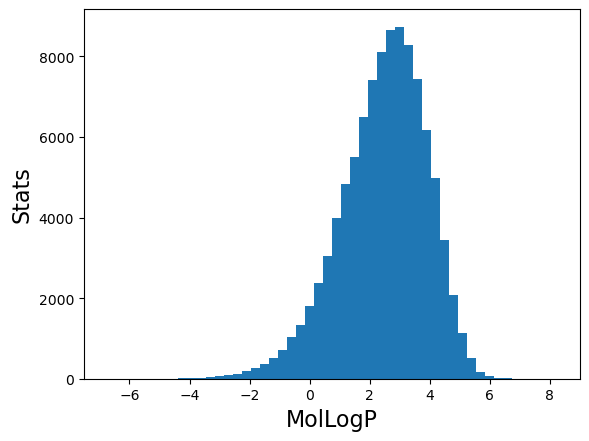

In [4]:
from rdkit.Chem import Descriptors

logps = [Descriptors.MolLogP(Chem.MolFromSmiles(s)) for s in subset]
mw = [Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in subset]

plt.hist(logps, bins = 50)
plt.xlabel('MolLogP', fontsize = 16)
plt.ylabel('Stats', fontsize = 16)

We canonicalized all SMILES using RDKit and verified that no duplicates were removed, confirming the dataset was already distributed in canonical form. This step ensures that train/val/test splits are made on unique molecules, eliminating potential data leakage

In [102]:
# 1. Canonicalize all SMILES
canon_smiles = [canonicalize(s) for s in subset if canonicalize(s) is not None]

# 2. Deduplicate
canon_unique = sorted(set(canon_smiles))
print("Original size:", len(subset))
print("Unique canonical size:", len(canon_unique))


Original size: 100000
Unique canonical size: 100000


Tokenization converts SMILES strings into sequences of tokens that can be mapped to integers and fed into the RNN. Without tokenization, the model cannot learn the sequential grammar of SMILES

In [71]:
# --- User-defined SMILES vocabulary/alphabet ---

VOCAB = [
    # Special tokens [padding, start, end, unknown symbol]
    "<PAD>", "<START>", "<END>", "<UNK>",

    # Common atoms
    "C", "O", "N", "S", "P", "F", "Cl", "Br", "I",

    # Aromatic atoms (lowercase form often used in SMILES)
    "c", "o", "n", "s", "p",

    # Bonds
    "-", "=", "#",

    # Branching / rings
    "(", ")", "[", "]",

    # Ring closure digits
    "1","2","3","4","5","6","7","8","9",
    
    # Stereo / charges
    "@", "@@", "+", "H"
]

# Build dictionaries: use increasing integer numbers for tokenization
stoi = {tok: i for i, tok in enumerate(VOCAB)}   # from tokens to integers
itos = {i: tok for tok, i in stoi.items()}     # from integers to tokens

{'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3, 'C': 4, 'O': 5, 'N': 6, 'S': 7, 'P': 8, 'F': 9, 'Cl': 10, 'Br': 11, 'I': 12, 'c': 13, 'o': 14, 'n': 15, 's': 16, 'p': 17, '-': 18, '=': 19, '#': 20, '(': 21, ')': 22, '[': 23, ']': 24, '1': 25, '2': 26, '3': 27, '4': 28, '5': 29, '6': 30, '7': 31, '8': 32, '9': 33, '@': 34, '@@': 35, '+': 36, 'H': 37}
{0: '<PAD>', 1: '<START>', 2: '<END>', 3: '<UNK>', 4: 'C', 5: 'O', 6: 'N', 7: 'S', 8: 'P', 9: 'F', 10: 'Cl', 11: 'Br', 12: 'I', 13: 'c', 14: 'o', 15: 'n', 16: 's', 17: 'p', 18: '-', 19: '=', 20: '#', 21: '(', 22: ')', 23: '[', 24: ']', 25: '1', 26: '2', 27: '3', 28: '4', 29: '5', 30: '6', 31: '7', 32: '8', 33: '9', 34: '@', 35: '@@', 36: '+', 37: 'H'}


In [73]:
def tokenize_manual(smiles: str):
    
    """ Takes in a SMILES string and returns the tokenization [split tokens into a string] """
    tokens = []
    i = 0
    while i < len(smiles):
        # check two-character tokens
        if smiles[i:i+2] in ("Cl", "Br", "@@"):
            tokens.append(smiles[i:i+2])
            i += 2
        else:
            tokens.append(smiles[i])
            i += 1
    return tokens

def encode(smiles):
    
    """ From SMILES representation to tokens: tokenization """
    
    tokens = ["<START>"] + tokenize_manual(smiles) + ["<END>"]
    unk_id = stoi["<UNK>"]
    return [stoi.get(t, unk_id) for t in tokens]

def decode(id_list):
    
    """ From integers to tokens: detokenize """    
    tokens = [itos[i] for i in id_list if itos[i] not in ("<PAD>", "<START>", "<END>")]
    return "".join(tokens)

# testing the tokenization/encoding/decoding process
test_smile = "CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1"
#test_smile = "C@@H"
print(f'Testing encoding and decoding for test SMILES {test_smile}')
# test
s = tokenize_manual(test_smile)
enc = encode(s)
print(f'Encoded representation = {enc}')
s_back = decode(enc)

assert s_back == test_smile

Testing encoding and decoding for test SMILES CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1
Encoded representation = [1, 4, 4, 21, 4, 22, 21, 4, 22, 13, 25, 13, 13, 13, 26, 14, 13, 13, 21, 4, 4, 21, 19, 5, 22, 6, 13, 27, 13, 13, 13, 13, 13, 27, 9, 22, 13, 26, 13, 25, 2]


SMILES have different lengths, so you’ll want them in a rectangular tensor for training.
Common approach: pad with <PAD> to the same length
    
Also, structure of input/target. Given a character in the sequence, the network learns the next one.
    
   Neural nets (and GPUs) like rectangular tensors: every batch must have the same shape (batch_size, max_len).
But molecules have different lengths, so we need to pad shorter sequences with a dummy token (<PAD>).

`<START> 1 3 5 7 <END>` padded to `<START> 1 3 5 7 <END> <PAD> <PAD> <PAD>`

In [74]:
def make_input_target(encoded):
    inp = encoded[:-1]
    tgt = encoded[1:]
    return inp, tgt

In [90]:
inputs = []
target = []

# integer corresponding to the padding entry
pad_id = stoi["<PAD>"]

def pad_sequence(encoded_sequences, padded_length = None):
    """ Padding and convert to a 2D array (then to be converted to a torch tensor) """
    
    all_padded = []

    if padded_length is None:
        padded_length = max(len(seq) for seq in encoded_sequences)
    
    for seq in encoded_sequences:
        
        added_pads = padded_length - len(seq)
        seq = seq + list(np.ones(added_pads) * pad_id)
        all_padded.append(seq)
        
    return np.array(all_padded, dtype=np.int64)

#test_smiles = ["CCO", "CC(=O)O", "HCl"]
for smile in subset[0:50000]:

    #print(encode(smile))
    inp, tgt = make_input_target(encode(smile))    
    inputs.append(inp)
    target.append(tgt)

assert len(inputs[0]) == len(target[0])

In [92]:
pad_length = 120     # this will have to be tuned according to the SMILES that we have

A = pad_sequence(inputs, pad_length)    #100
B = pad_sequence(target, pad_length)    #100

print(A.shape, B.shape)

(50000, 120) (50000, 120)


#### now we need to call torch tensorDataset and dataLoader. These are for "plain" tensor data, whereras "pyg.data and dataloader" are for graph objects; I used those for the GNN project

A single sample is a whole graph vs a row $(x[i], y[i])$, batching requires stacking along the first diemnsion vs concatenate graphs

#### convert to `torch`, define `DataLoader` objects for train, validation and test

In [95]:
x = torch.from_numpy(A).long()
y = torch.from_numpy(B).long()

dataset = TensorDataset(x, y)
N = len(dataset)

n_train = int(0.8 * N)
n_val   = int(0.1 * N)
n_test  = N - n_train - n_val

print(f"train={n_train}, val={n_val}, test={n_test}")
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test],generator=torch.Generator().manual_seed(42))  # reproducible split

batch_size = 128

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size)
test_loader  = DataLoader(test_ds, batch_size=batch_size)

print(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

train=40000, val=5000, test=5000
40000 5000 5000


<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">
    
The problem we have at hand is a multi-class classification (**Pick the correct token ID from a discrete vocabulary**), so the head is a multi-class classifier acting on the output of a NN, which happens to be a recurrent network to keep track of the order in the sequences

SmilesGRU is essentially a next-token predictor for SMILES. It learns embeddings, processes them sequentially with GRU memory, and classifies each step over the vocabulary

</div>

**embedding layer** essentially it is a trainable token to vector dctionary; similar to a `Linear` layer, with some features that are well-suited for tokens like SMILES symbols
One could one-hot encode the token and apply a linear layer to project to `emb_dim`, that would be equivalent. But `embedding` is much more efficient

Learns distributed representations of tokens, so chemically similar tokes may get similar embeddings

The embedding layer does not produce one single vector for the whole SMILES, it produces a sequence of vectors (one per token) so that the GRU can process them step-by-step, mantaining order

The GRU threads them together across time, carrying memory in the hidden state. The linear projection maps that memory to “which token comes next?”

In [96]:
class SmilesGRU(nn.Module):
    def __init__(self, vocab_size, pad_id=0, emb_dim=128, hidden_dim=256, num_layers=1, dropout=0.0, use_lstm=False, tie_weights=True):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)     #embedding layer, pad_id ignored during training
                                                                               # turn each token ID (int) into a dense vector of size `emb_dim`
        rnn_cls = nn.LSTM if use_lstm else nn.GRU     # process the sequence step by step
        self.rnn = rnn_cls(       # this is the actual RNN that will process the sequences of tokens at each time step
            emb_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.proj = nn.Linear(hidden_dim, vocab_size, bias=True)
        
        if tie_weights:
            assert emb_dim == hidden_dim, "Weight tying requires emb_dim == hidden_dim"
            self.proj.weight = self.embed.weight  # share parameters

    def forward(self, x, h0=None):
        e = self.embed(x)         # (B, T, E)
        y, h = self.rnn(e, h0)    # (B, T, H)     # hidden states are returned together with outputs, if None, then all 0s
        logits = self.proj(y)    # takes the hidden state at each position (B, T, H) and map to (B, T, V)
                                                                  # this is the actual multi-classification HEAD: at each time, predict next token
        return logits     # ready for cross-entropy

In [97]:
# Basic checks
print("vocab_size:", len(stoi))
pad_id = stoi.get("<PAD>", None)
unk_id = stoi.get("<UNK>", None)
print("pad_id:", pad_id, "unk_id:", unk_id)

def check_tensor(name, t):
    print(f"\n{name} shape: {tuple(t.shape)} dtype:{t.dtype}")
    tmin = int(t.min().item())
    tmax = int(t.max().item())
    print(f"{name} min:{tmin} max:{tmax}")
    bad_lo = (t < 0).nonzero(as_tuple=False)
    bad_hi = (t >= len(stoi)).nonzero(as_tuple=False)
    print(f"{name} <0 count:", bad_lo.size(0), "| >=vocab count:", bad_hi.size(0))
    if bad_lo.size(0) > 0:
        print("example <0 index:", t[tuple(bad_lo[0].tolist())].item(), "at", bad_lo[0].tolist())
    if bad_hi.size(0) > 0:
        print("example >=vocab index:", t[tuple(bad_hi[0].tolist())].item(), "at", bad_hi[0].tolist())

# Check both inputs/targets from the loader (first batch)
xb, yb = next(iter(train_loader))
check_tensor("xb", xb)
check_tensor("yb", yb)

vocab_size: 38
pad_id: 0 unk_id: 3

xb shape: (128, 120) dtype:torch.int64
xb min:0 max:37
xb <0 count: 0 | >=vocab count: 0

yb shape: (128, 120) dtype:torch.int64
yb min:0 max:37
yb <0 count: 0 | >=vocab count: 0


In [98]:
vocab_size = len(stoi)   # your vocab
print(f'Vocabulary size (number of letters, tokens) = {vocab_size}')
pad_id = stoi["<PAD>"]   # 0 in your setup

model = SmilesGRU(
    vocab_size=vocab_size,
    pad_id=pad_id,
    emb_dim=128,
    hidden_dim=128,       # 128 here to allow weight tying (emb=hidden)
    num_layers=1,
    dropout=0.0,
    use_lstm=False,
    tie_weights=True
).to(device)

print(model)


# define loss and optimizer
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)     # ignore padding for padded encoded SMILES tensors
optimizer = optim.Adam(model.parameters(), lr=2e-3)

def run_epoch(loader, train=True, clip=1.0):
    model.train(train)
    total_loss, total_tokens = 0.0, 0
    
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            optimizer.zero_grad()
        pred = model(xb)                            # (B,T,V)
        labels = yb.reshape(-1)
        
                         # predictions from the NN        # actual target from the data to compare against
        loss = loss_fn(pred.reshape(-1, vocab_size), labels)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            
        # count non-PAD targets for averaging
        ntok = (yb != pad_id).sum().item()
        total_loss += loss.item() * max(ntok, 1)
        total_tokens += max(ntok, 1)
    return total_loss / total_tokens      # this ensures fair averaging per token, regarless of seqeucne length.
                                          # wthout this, the reported loss would be biased toward short or long SMILES

train_losses, val_losses = [], []

best_val = float("inf")
for epoch in range(1, 100):  # start with ~5 epochs; adjust after you see curves
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)

    train_losses.append(tr)
    val_losses.append(va)
    
    print(f"epoch {epoch} | train CE {tr:.4f} | val CE {va:.4f} | ppl {math.exp(va):.2f}")
    if va < best_val - 1e-4:
        best_val = va
        torch.save(model.state_dict(), "smiles_gru.pt")
model.load_state_dict(torch.load("smiles_gru.pt", map_location=device))
model.eval()

# plot perplexity
plt.plot(np.exp(train_losses), label="Train PPL")
plt.plot(np.exp(val_losses),   label="Val PPL")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Training & Validation Perplexity")
plt.legend()
plt.grid(True)
plt.show()

Vocabulary size (number of letters, tokens) = 38
SmilesGRU(
  (embed): Embedding(38, 128, padding_idx=0)
  (rnn): GRU(128, 128, batch_first=True)
  (proj): Linear(in_features=128, out_features=38, bias=True)
)
epoch 1 | train CE 1.1167 | val CE 0.9018 | ppl 2.46
epoch 2 | train CE 0.8522 | val CE 0.8250 | ppl 2.28
epoch 3 | train CE 0.7997 | val CE 0.7832 | ppl 2.19
epoch 4 | train CE 0.7675 | val CE 0.7606 | ppl 2.14
epoch 5 | train CE 0.7446 | val CE 0.7377 | ppl 2.09
epoch 6 | train CE 0.7303 | val CE 0.7387 | ppl 2.09
epoch 7 | train CE 0.7179 | val CE 0.7169 | ppl 2.05
epoch 8 | train CE 0.7079 | val CE 0.7139 | ppl 2.04
epoch 9 | train CE 0.7003 | val CE 0.7067 | ppl 2.03
epoch 10 | train CE 0.6952 | val CE 0.6991 | ppl 2.01
epoch 11 | train CE 0.6885 | val CE 0.6970 | ppl 2.01
epoch 12 | train CE 0.6830 | val CE 0.6942 | ppl 2.00
epoch 13 | train CE 0.6799 | val CE 0.6897 | ppl 1.99
epoch 14 | train CE 0.6760 | val CE 0.6909 | ppl 2.00
epoch 15 | train CE 0.6720 | val CE 0.6843 

KeyboardInterrupt: 

## testing

In [99]:
model.eval()

loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)
total_loss, total_tokens = 0.0, 0

# disable gradien tracking, we don't need it
with torch.no_grad():
    for xb, yb in test_loader:  # from earlier splitting
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)  # (B, T, V)
        loss = loss_fn(pred.view(-1, vocab_size), yb.view(-1))

        ntok = (yb != pad_id).sum().item()
        total_loss += loss.item() * ntok
        total_tokens += ntok

test_loss = total_loss / total_tokens
test_ppl = math.exp(test_loss)

print(f"Test CE: {test_loss:.4f} | Test Perplexity: {test_ppl:.2f}")

Test CE: 0.6673 | Test Perplexity: 1.95


### autoregressive geneeration: use the distribution learned from the model (TO CODE)
- start with `<START>`
- predict next-token distribution
- sample next token
- append, repeat until `<END>` (or the max length is reached)
- check validity with RDKit

In [ ]:
turn your trained GRU into a generator and display results. It uses the simple “re-feed the whole prefix” method (no hidden-state juggling)

<div style="background-color: lightyellow; padding: 10px; border-radius: 5px;">
    
**Why RNNs struggle with sequences**
Recurrent neural networks (RNNs), including LSTMs and GRUs, process sequences token by token, updating a hidden state that carries information from the past. While this makes them naturally suited for ordered data like SMILES strings, it also creates two limitations. 
- First, RNNs are inherently sequential: each step depends on the previous one, so they cannot be fully parallelized during training, which slows them down on large datasets.
- Second, all context must be squeezed through a single evolving hidden state, which makes it hard for the model to capture long-range dependencies (e.g., an opening parenthesis and its matching closure many tokens later).
These bottlenecks often lead to vanishing gradients and degraded performance on long sequences.

**Why Transformers are better**
Transformers replace recurrence with self-attention, a mechanism where each token can directly “look at” every other token in the sequence. This change brings two decisive advantages:
- Transformers can process all tokens in parallel, massively speeding up training and making them more scalable;
- they handle long-range context naturally, since attention allows even distant tokens to interact without being compressed into a single hidden state.
In practice, this makes Transformers the dominant architecture for modern sequence modeling tasks, from natural language to molecular SMILES generation.

</div>